In [1]:
from pathlib import Path
import sys
from dataclasses import replace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / 'src' / 'xp_config.py').is_file() and (p / 'experiment').is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.xp_config import ExperimentConfig
from src.experiment import estimate_config
from src.fidelities import fidelities_over_time
from experiment.sweep_D_fidelity import run_coupling_sweep

# Figure style from calibration_twophoton_waveguideQED, editable here.
colors = ['#003f5c', '#8e3e7a', '#ed9a00', '#2a4a79', '#c64f8b']
plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'axes.linewidth': 0.7,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'axes.prop_cycle': plt.cycler(color=colors),
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'legend.frameon': False,
    'lines.linewidth': 1.0,
    'lines.markersize': 3,
    'figure.dpi': 300,
})
pd.set_option('display.float_format', '{:.9g}'.format)


# Fidelities versus the physical coupling D

Parameters follow the D, sigma_k and x_tls conventions. The coupling profile is `sqrt`, as in Uri's experiments.
Numerical functions live in `experiment/`; this notebook controls their inputs and displays results.
See the [mathematical and code documentation](../documentation/main.pdf).


## Parameters


In [2]:
CTRL_M_EXPLICIT = True
M = 5                         # Must be odd; k=0 is included.
cutoffs = {'ir_cutoff': 0.0, 'uv_cutoff': 2.0}  # Used only when control is False.

param_atom = {'omega_0': 1.0, 'D': 0.2, 'L': 2*np.pi,
              'x_tls': 0.0, 'coupling': 'sqrt', 'initial_state': 'g'}
param_photon = {'k_0': 1.0, 'sigma_k': 0.4, 'x_0': -2.0,
                'state': 'number', 'n': 1, 'alpha': 1.0}
param_time_evol = {'T': 4.0, 'dt': 0.05, 'rtol': 1e-9, 'atol': 1e-11}
n_max = 2
truncation = 'full+totalcap'
RWA = False

config = ExperimentConfig(param_photon, param_atom, param_time_evol, cutoffs,
                          n_max=n_max, truncation=truncation, RWA=RWA,
                          CTRL_M_EXPLICIT=CTRL_M_EXPLICIT, M=M)


## Resource estimate

Informative only: the estimate does not stop execution. Memory covers retained complex vectors and excludes sparse matrices, Python objects and solver workspace.

In [3]:
D_values = np.geomspace(0.02, 0.4, 5)
schemes = ('truncated',)
# Simulated comparator; full remains the implicit ambient overlap basis.
reference = 'full+totalcap'
estimate = pd.concat([estimate_config(replace(config, truncation=s))
                      for s in (*schemes, reference)],
                     keys=(*schemes, reference), names=['scheme'])
display(estimate)

Value
scheme        Group  Parameter                          
truncated     Cavity omega_0                           1
                     D                               0.2
                     L                        6.28318531
                     x_tls                             0
                     coupling                       sqrt
                     initial_state                     g
              Modes  M                                 5
                     delta_k                           1
                     k_min                            -2
                     k_max                             2
                     IR_effective                      0
                     UV_effective                      2
              Time   T                                 4
                     dt                             0.05
                     rtol                          1e-09
                     atol                          1e-11
                     n_outputs                        81
              Memory basis                     truncated
                     n_max                             2
                     dimension                        22
                     store_state                    True
                     ket_GiB              3.27825546e-07
                     history_GiB          2.65538692e-05
                     retained_vectors_GiB 5.31077385e-05
full+totalcap Cavity omega_0                           1
                     D                               0.2
                     L                        6.28318531
                     x_tls                             0
                     coupling                       sqrt
                     initial_state                     g
              Modes  M                                 5
                     delta_k                           1
                     k_min                            -2
                     k_max                             2
                     IR_effective                      0
                     UV_effective                      2
              Time   T                                 4
                     dt                             0.05
                     rtol                          1e-09
                     atol                          1e-11
                     n_outputs                        81
              Memory basis                 full+totalcap
                     n_max                             2
                     dimension                        42
                     store_state                    True
                     ket_GiB               6.2584877e-07
                     history_GiB          5.06937504e-05
                     retained_vectors_GiB 0.000101387501

## Data generation

The associated Python module only generates numerical data.

In [4]:
results = run_coupling_sweep(config, D_values, schemes, reference)

## Postprocessing

Prepare the arrays and DataFrames used by the plots below.

In [5]:
fidelity_table = pd.DataFrame({
    f'{name}_{stage}': (results[f'{name}_initial'] if stage == 'initial' else results[name]).ravel()
    for name in ('F_state', 'F_atom') for stage in ('initial', 'time_mean')
}, index=pd.MultiIndex.from_product([results['schemes'], results['D']], names=['scheme', 'D']))
display(fidelity_table)

F_state_initial  ...  F_atom_time_mean
scheme    D                              ...                  
truncated 0.02                        1  ...       0.999991709
          0.0422948505                1  ...       0.999962967
          0.0894427191                1  ...        0.99983525
          0.189148322                 1  ...       0.999278426
          0.4                         1  ...       0.996917568

[5 rows x 4 columns]

## Plots

All drawing code is visible and editable here.

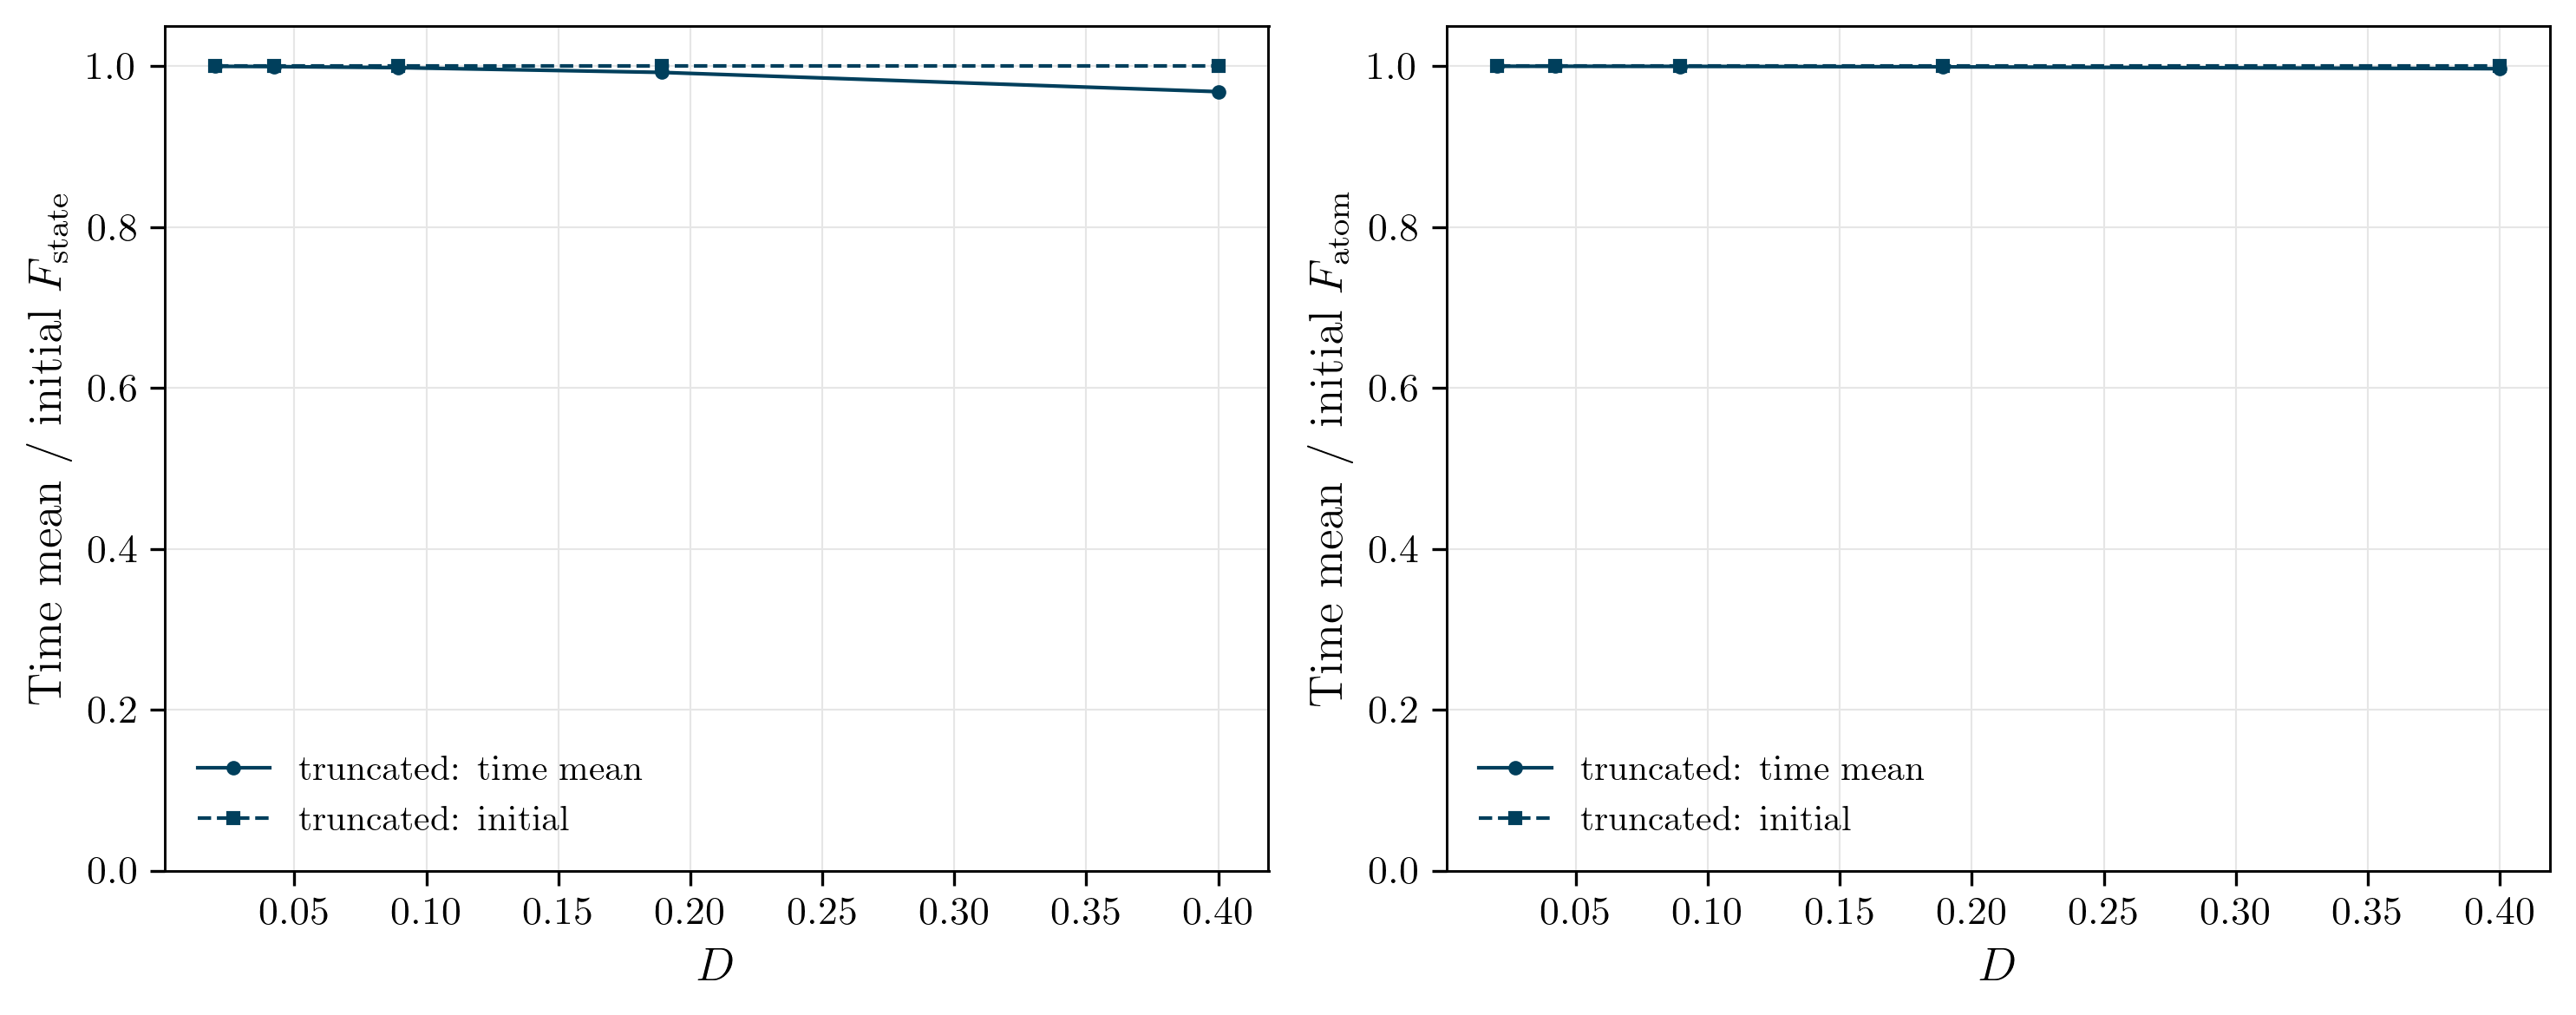

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, name, label in zip(axes, ('F_state', 'F_atom'), (r'$F_{\mathrm{state}}$', r'$F_{\mathrm{atom}}$')):
    for j, scheme in enumerate(results['schemes']):
        color = colors[j % len(colors)]
        ax.plot(results['D'], results[name][j], 'o-', color=color, label=f'{scheme}: time mean')
        ax.plot(results['D'], results[f'{name}_initial'][j], 's--', color=color, label=f'{scheme}: initial')
    ax.set(xlabel=r'$D$', ylabel='Time mean / initial ' + label, ylim=(0, 1.05))
    ax.legend()
for ax in axes.flat:
    ax.grid(color='0.9', linestyle='-', linewidth=0.5)
    ax.tick_params(length=4, width=0.8)
fig.tight_layout()
plt.show()